# Debug Model: Logit Analysis of Correct vs Misclassified Samples

Run the trained model on the test set and compare the raw logit distributions for correctly classified and misclassified samples.

In [1]:
import torch
import torch.nn.functional as F
import timm
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets
from torch.utils.data import DataLoader

NUM_CLASSES = 46
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=NUM_CLASSES)
model.load_state_dict(torch.load("fruit_classifier_46cls_b0.pth", map_location=device))
model = model.to(device)
model.eval()

config = timm.data.resolve_model_data_config(model)
transform = timm.data.create_transform(**config, is_training=False)
test_ds = datasets.ImageFolder("PrepData/Test", transform=transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

class_names = test_ds.classes
print(f"Device: {device}")
print(f"Test samples: {len(test_ds)}")
print(f"Classes ({len(class_names)}): {class_names}")

Device: cuda
Test samples: 5077
Classes (46): ['Chinese_chestnut', 'Dangshan_Pear', 'Hami_melon', 'almond', 'annona_muricata', 'apple', 'apricot', 'artocarpus_heterophyllus', 'avocado', 'banana', 'bayberry', 'bergamot_pear', 'black_currant', 'black_grape', 'blood_orange', 'blueberry', 'breadfruit', 'candied_date', 'carambola', 'cashew_nut', 'cherry', 'cherry_tomato', 'citrus', 'coconut', 'crown_pear', 'dekopon', 'diospyros_lotus', 'durian', 'fig', 'flat_peach', 'gandaria', 'ginseng_fruit', 'golden_melon', 'grape', 'grape_white', 'grapefruit', 'green_apple', 'green_dates', 'guava', 'hawthorn', 'hazelnut', 'hickory', 'honey_dew_melon', 'housi_pear', 'juicy_peach', 'jujube']


## 1. Collect Logits for All Test Samples

In [2]:
all_logits = []
all_labels = []
all_preds = []
all_images = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1)

        all_logits.append(logits.cpu())
        all_labels.append(labels)
        all_preds.append(preds.cpu())
        all_images.append(images.cpu())

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels)
all_preds = torch.cat(all_preds)
all_images = torch.cat(all_images)
all_probs = F.softmax(all_logits, dim=1)

correct_mask = all_preds == all_labels
n_correct = correct_mask.sum().item()
n_wrong = (~correct_mask).sum().item()
print(f"Correct: {n_correct}, Misclassified: {n_wrong} ({100*n_wrong/len(all_labels):.1f}%)")

Correct: 3563, Misclassified: 1514 (29.8%)


## 2. Confidence Distribution: Correct vs Misclassified

Compare the predicted-class probability (confidence) for correctly vs incorrectly classified samples.

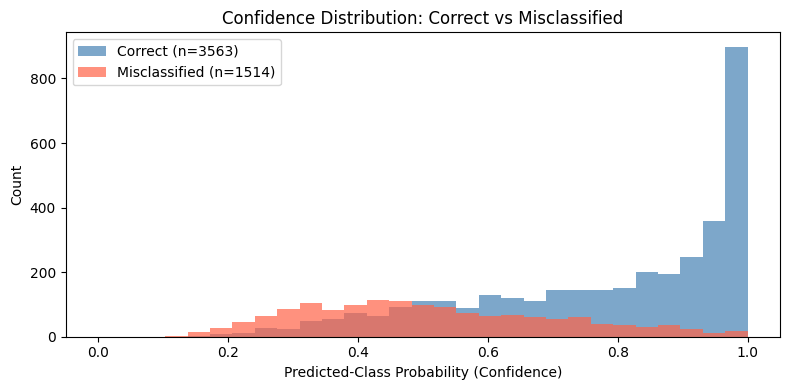

In [3]:
correct_conf = all_probs[correct_mask].max(dim=1).values.numpy()
wrong_conf = all_probs[~correct_mask].max(dim=1).values.numpy()

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 30)
ax.hist(correct_conf, bins=bins, alpha=0.7, label=f"Correct (n={n_correct})", color="steelblue")
if n_wrong > 0:
    ax.hist(wrong_conf, bins=bins, alpha=0.7, label=f"Misclassified (n={n_wrong})", color="tomato")
ax.set_xlabel("Predicted-Class Probability (Confidence)")
ax.set_ylabel("Count")
ax.set_title("Confidence Distribution: Correct vs Misclassified")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Logit Bar Charts: Misclassified Samples

Show the image alongside its full logit distribution for each misclassified sample (or a subset if there are many).

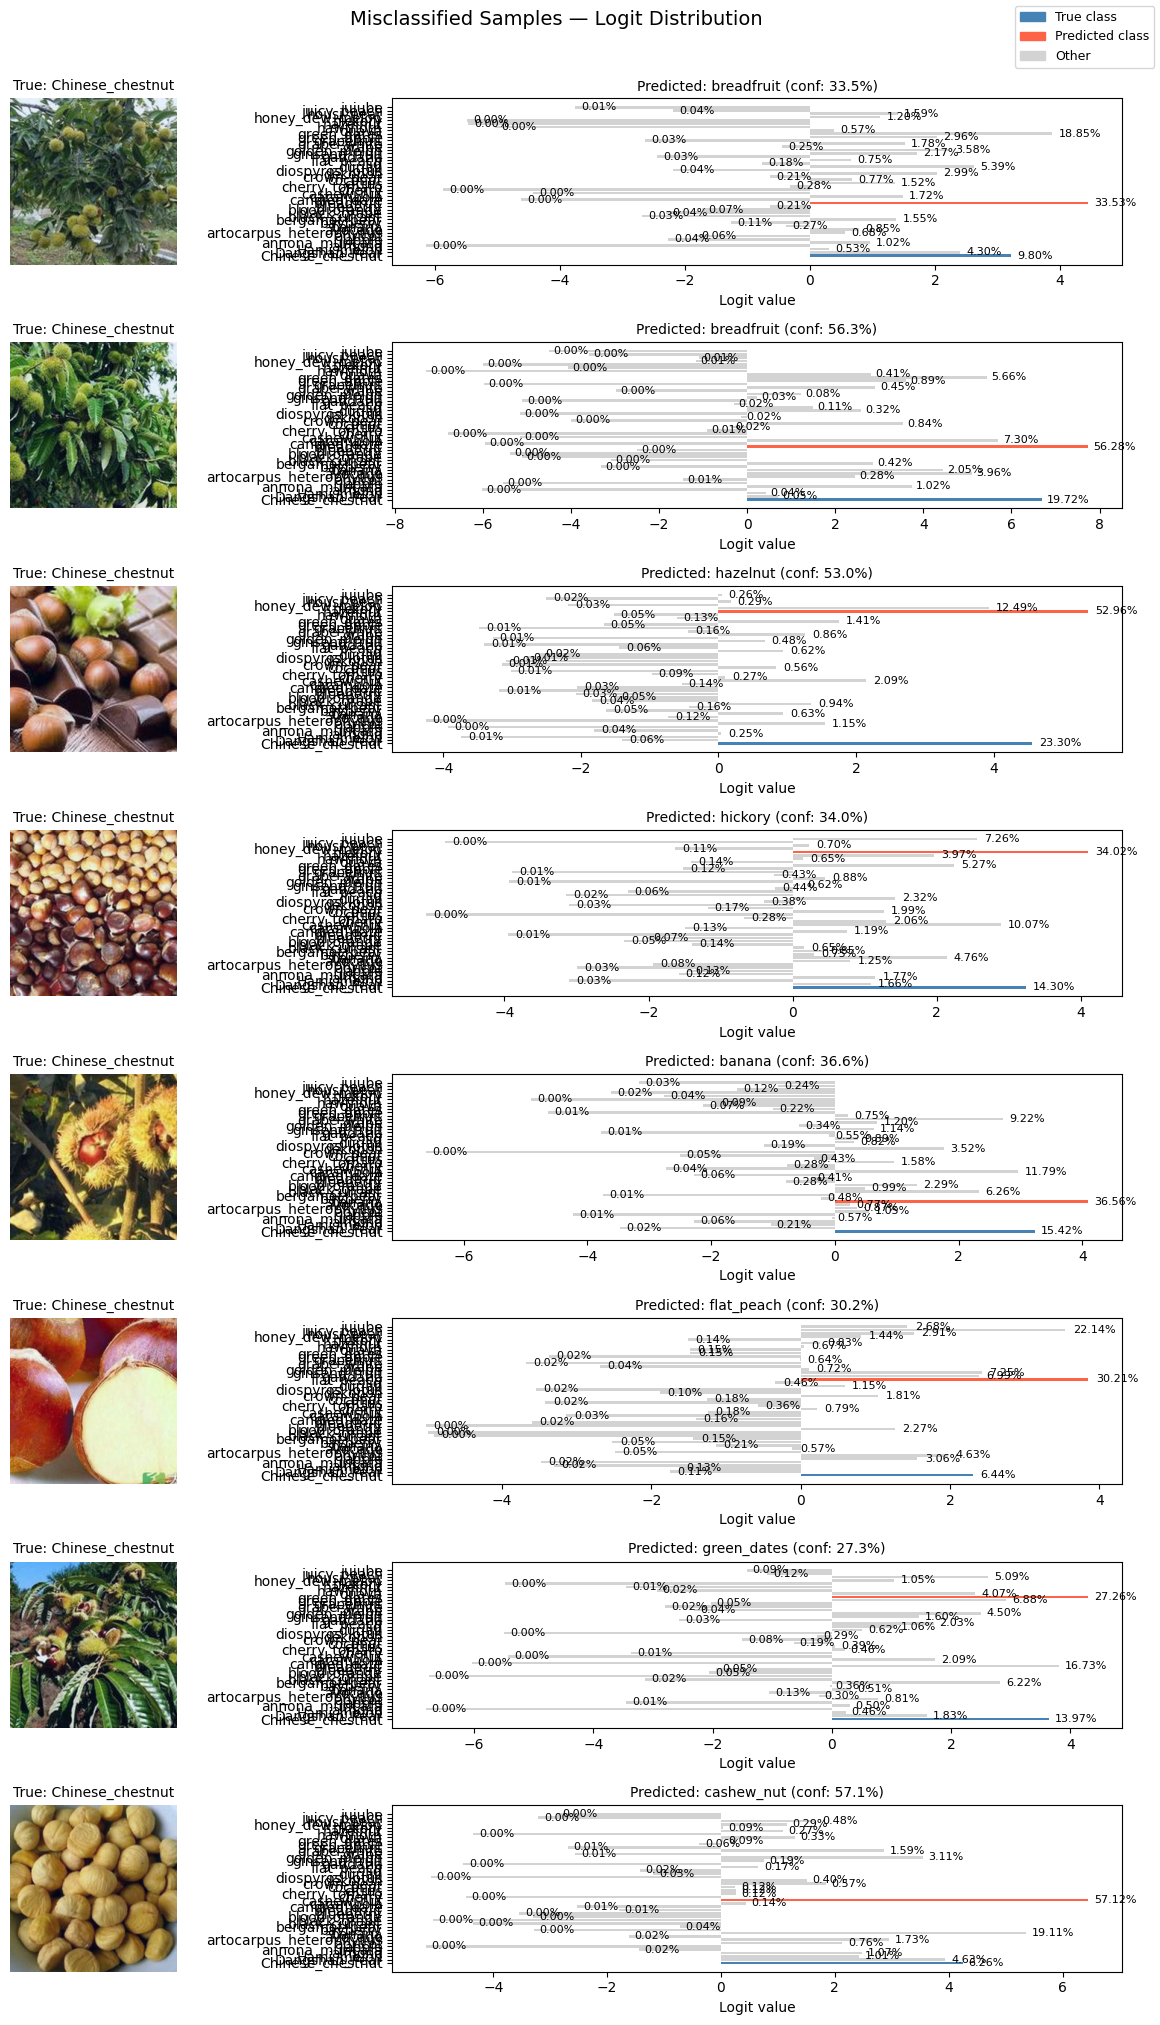

In [4]:
def denorm_image(img_tensor):
    """Convert normalized tensor back to displayable [0,1] RGB image."""
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img

def plot_logit_bars(indices, title, max_show=8):
    """Plot image + logit bar chart side by side for given sample indices."""
    indices = indices[:max_show]
    n = len(indices)
    if n == 0:
        print(f"No samples to show for: {title}")
        return

    fig, axes = plt.subplots(n, 2, figsize=(12, 2.5 * n),
                             gridspec_kw={"width_ratios": [1, 3]})
    fig.suptitle(title, fontsize=14, y=1.01)
    if n == 1:
        axes = axes.reshape(1, 2)

    for row, idx in enumerate(indices):
        logits = all_logits[idx].numpy()
        probs = all_probs[idx].numpy()
        true_label = all_labels[idx].item()
        pred_label = all_preds[idx].item()

        # Image
        axes[row, 0].imshow(denorm_image(all_images[idx]))
        axes[row, 0].set_title(f"True: {class_names[true_label]}", fontsize=10)
        axes[row, 0].axis('off')

        # Logit bar chart
        colors = ['tomato' if i == pred_label else 'lightgray' for i in range(len(class_names))]
        colors[true_label] = 'steelblue'
        bars = axes[row, 1].barh(class_names, logits, color=colors)
        axes[row, 1].set_xlabel("Logit value")

        # Annotate bars with probabilities
        for i, (bar, p) in enumerate(zip(bars, probs)):
            x = bar.get_width()
            axes[row, 1].text(x + 0.1, bar.get_y() + bar.get_height()/2,
                              f"{p:.2%}", va='center', fontsize=8)

        axes[row, 1].set_title(f"Predicted: {class_names[pred_label]} (conf: {probs[pred_label]:.1%})",
                                fontsize=10)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(color='steelblue', label='True class'),
                       Patch(color='tomato', label='Predicted class'),
                       Patch(color='lightgray', label='Other')]
    fig.legend(handles=legend_elements, loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

# Show misclassified samples
wrong_indices = torch.where(~correct_mask)[0].tolist()
plot_logit_bars(wrong_indices, "Misclassified Samples — Logit Distribution")

## 4. Logit Bar Charts: Correctly Classified Samples

Show a random subset of correct predictions for comparison — these should have a single dominant logit on the true class.

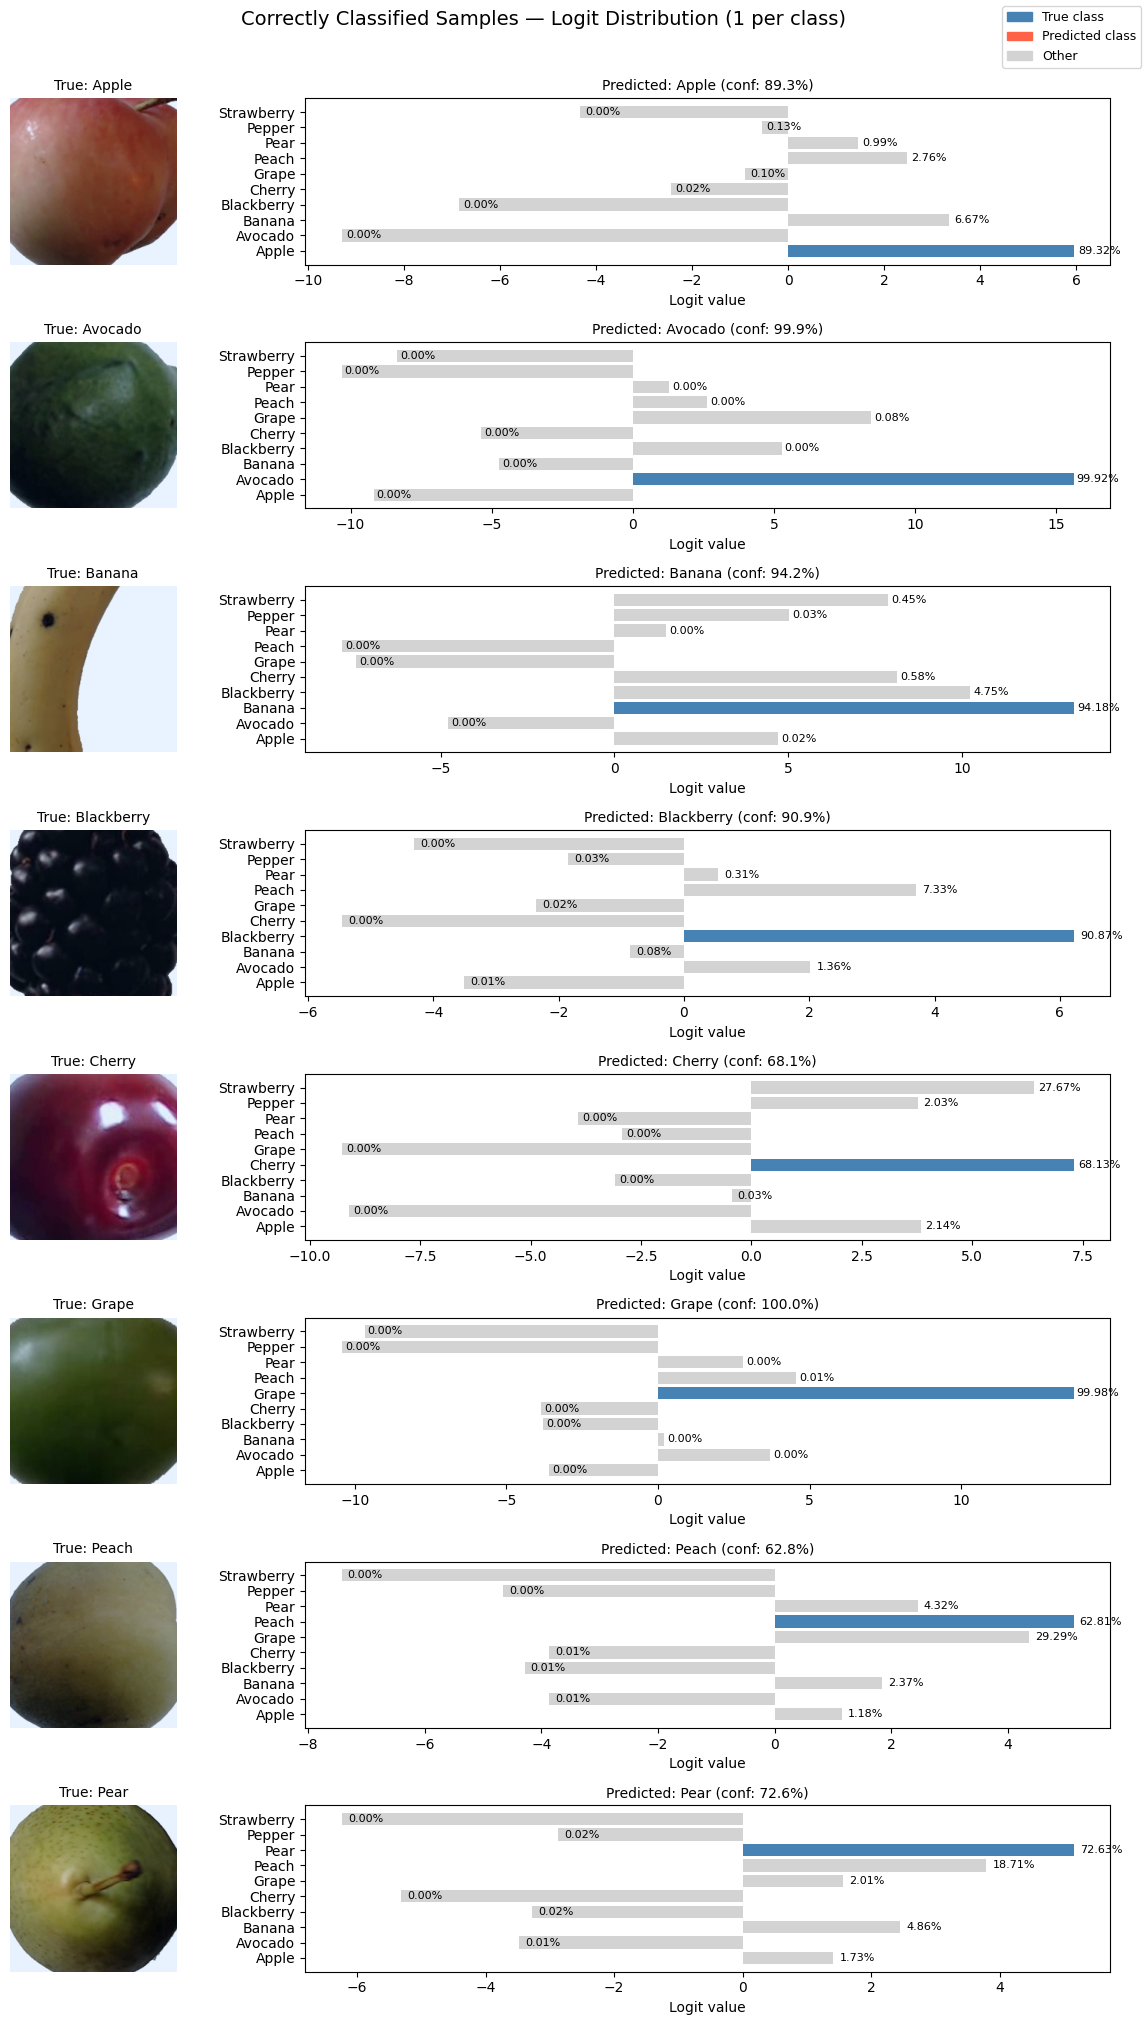

In [5]:
# Pick one random correct sample per class for variety
rng = np.random.default_rng(42)
correct_indices = []
for cls_idx in range(len(class_names)):
    cls_correct = torch.where(correct_mask & (all_labels == cls_idx))[0].tolist()
    if cls_correct:
        correct_indices.append(rng.choice(cls_correct))

plot_logit_bars(correct_indices, "Correctly Classified Samples — Logit Distribution (1 per class)")